# 🌍 Air Quality in India: Pollution Trends, City Comparison & AQI Prediction

**Data Visualization, Environmental Insights & Machine Learning**

Air pollution is one of the most serious environmental health risks worldwide. In this notebook we explore
daily air-quality data across multiple Indian cities, analyze pollution levels and AQI distribution, and
finally train a regression model that predicts the AQI from pollutant readings.

📊 **Dataset:** a realistic, fully **synthetic** dataset (`data/city_day.csv`) generated by
`src/generate_dataset.py`, built to statistically resemble the real-world CPCB *"Air Quality Data in India"*
dataset — same columns, same city-level pollution patterns, same seasonal cycles — but with **no internet
connection, Kaggle account, or external download required**. Everything in this notebook runs fully offline,
right from this folder.


## Data Overview

The dataset includes daily measurements of major air pollutants along with the Air Quality Index (AQI).

**Pollutants included:**
- **PM2.5** – Fine particulate matter smaller than 2.5 micrometers
- **PM10** – Particulate matter smaller than 10 micrometers
- **NO, NO₂, NOx** – Emitted mainly from vehicles and industrial activity
- **NH₃** – Ammonia
- **SO₂** – Produced by burning fossil fuels
- **CO** – Produced by incomplete combustion
- **O₃, Benzene, Toluene, Xylene** – Ground-level ozone and volatile organic compounds
- **AQI** – A standardized index used to report overall air quality

**Additional contextual columns:** City name, Date of measurement, AQI_Bucket (category label).


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import datetime as dt

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Data Loading

Unlike the original version of this analysis (which pulled data from Kaggle via `kagglehub`), this
notebook loads data straight from the **`data/city_day.csv`** file included in this project folder.

> Don't have the file yet? Run `python src/generate_dataset.py` from the project root once, then re-run this
> notebook.

In [2]:
import os

DATA_PATH = os.path.join("..", "data", "city_day.csv")

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        "data/city_day.csv not found. Run `python src/generate_dataset.py` "
        "from the project root first."
    )

print("Using dataset:", os.path.abspath(DATA_PATH))

Using dataset: /home/claude/AQI_India_Project/data/city_day.csv


In [3]:
df = pd.read_csv(DATA_PATH)
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Delhi,2015-01-01,266.62,429.18,48.79,76.94,98.25,62.37,4.25,51.55,48.69,12.98,34.28,3.81,398.0,Very Poor
1,Delhi,2015-01-02,203.12,368.46,36.46,61.45,85.09,NaN,1.68,25.56,47.10,7.98,8.69,2.61,370.0,Very Poor
2,Delhi,2015-01-03,NaN,471.94,49.98,119.38,136.47,84.58,4.93,44.18,45.54,10.59,18.92,5.51,424.0,Severe
3,Delhi,2015-01-04,299.22,488.12,47.03,106.67,118.81,79.26,4.23,39.68,46.02,7.80,14.21,3.73,440.0,Severe
4,Delhi,2015-01-05,163.41,285.98,23.80,55.08,60.87,48.59,1.76,31.74,30.34,6.67,13.94,2.52,342.0,Very Poor


In [4]:
df.shape

(52208, 16)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52208 entries, 0 to 52207
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        52208 non-null  str    
 1   Date        52208 non-null  str    
 2   PM2.5       49043 non-null  float64
 3   PM10        49072 non-null  float64
 4   NO          49136 non-null  float64
 5   NO2         49072 non-null  float64
 6   NOx         49076 non-null  float64
 7   NH3         49016 non-null  float64
 8   CO          49029 non-null  float64
 9   SO2         49175 non-null  float64
 10  O3          49075 non-null  float64
 11  Benzene     49032 non-null  float64
 12  Toluene     49056 non-null  float64
 13  Xylene      49154 non-null  float64
 14  AQI         49064 non-null  float64
 15  AQI_Bucket  49064 non-null  str    
dtypes: float64(13), str(3)
memory usage: 7.7 MB


In [6]:
df.isnull().sum()

City             0
Date             0
PM2.5         3165
PM10          3136
NO            3072
NO2           3136
NOx           3132
NH3           3192
CO            3179
SO2           3033
O3            3133
Benzene       3176
Toluene       3152
Xylene        3054
AQI           3144
AQI_Bucket    3144
dtype: int64

In [7]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,49043.000000,49072.000000,49136.000000,49072.000000,49076.000000,49016.000000,49029.000000,49175.000000,49075.000000,49032.000000,49056.000000,49154.000000,49064.000000
mean,88.516713,146.025727,15.624400,36.448140,46.576638,20.793291,1.312933,15.623654,50.362022,3.107356,8.346098,2.078955,181.841472
std,50.278745,84.801784,9.289698,21.674303,27.662404,12.898400,0.824672,9.688564,16.100594,2.131110,5.728417,1.428007,104.934798
min,5.000000,10.000000,1.310000,3.100000,3.400000,1.730000,0.110000,1.210000,21.010000,0.180000,0.470000,0.130000,15.000000
25%,51.140000,83.770000,8.770000,20.470000,26.130000,11.390000,0.710000,8.530000,37.910000,1.560000,4.190000,1.050000,89.000000
50%,77.720000,127.765000,13.435000,31.300000,39.980000,17.620000,1.110000,13.280000,48.370000,2.550000,6.830000,1.710000,159.000000
75%,115.370000,190.745000,20.250000,47.150000,60.300000,26.900000,1.700000,20.260000,61.590000,4.060000,10.950000,2.710000,284.000000
max,377.160000,600.000000,77.580000,150.000000,200.000000,107.920000,7.120000,80.450000,98.700000,18.400000,50.430000,11.610000,500.000000


## EDA & Data Cleaning

In [8]:
df["Date"] = pd.to_datetime(df["Date"])
df.duplicated().sum()

np.int64(0)

In [9]:
cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI']

df[cols] = df[cols].fillna(df[cols].mean().round(2))

df['AQI_Bucket'].unique()

<ArrowStringArray>
['Very Poor', 'Severe', nan, 'Poor', 'Moderate', 'Satisfactory', 'Good']
Length: 7, dtype: str

In [10]:
bins = [0, 50, 100, 200, 300, 400, 500]
labels = [
    "Good",
    "Satisfactory",
    "Moderate",
    "Poor",
    "Very Poor",
    "Severe"
]

df["AQI_Bucket"] = df["AQI_Bucket"].fillna(
    pd.cut(df["AQI"], bins=bins, labels=labels)
)

In [11]:
aqi_map = {
    "Good": 1,
    "Satisfactory": 2,
    "Moderate": 3,
    "Poor": 4,
    "Very Poor": 5,
    "Severe": 6
}
df["AQI_Level"] = df["AQI_Bucket"].map(aqi_map)
df.isnull().sum()

City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
AQI_Level     0
dtype: int64

## Feature Engineering

In [12]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

df["Month"].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int32)

In [13]:
season_map = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Summer", 4: "Summer", 5: "Summer",
    6: "Monsoon", 7: "Monsoon", 8: "Monsoon", 9: "Monsoon",
    10: "Post-Monsoon", 11: "Post-Monsoon"
}

df["Season"] = df["Month"].map(season_map)

In [14]:
df[["Month", "Season"]].sample(10)

,Month,Season
49338,2,Winter
50401,7,Monsoon
40397,8,Monsoon
3388,10,Post-Monsoon
19477,11,Post-Monsoon
16961,6,Monsoon
12294,9,Monsoon
47832,7,Monsoon
24425,11,Post-Monsoon
45297,1,Winter


In [15]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,Benzene,Toluene,Xylene,AQI,AQI_Bucket,AQI_Level,Year,Month,Day,Season
0,Delhi,2015-01-01,266.62,429.18,48.79,76.94,98.25,62.37,4.25,51.55,...,12.98,34.28,3.81,398.0,Very Poor,5,2015,1,1,Winter
1,Delhi,2015-01-02,203.12,368.46,36.46,61.45,85.09,20.79,1.68,25.56,...,7.98,8.69,2.61,370.0,Very Poor,5,2015,1,2,Winter
2,Delhi,2015-01-03,88.52,471.94,49.98,119.38,136.47,84.58,4.93,44.18,...,10.59,18.92,5.51,424.0,Severe,6,2015,1,3,Winter
3,Delhi,2015-01-04,299.22,488.12,47.03,106.67,118.81,79.26,4.23,39.68,...,7.80,14.21,3.73,440.0,Severe,6,2015,1,4,Winter
4,Delhi,2015-01-05,163.41,285.98,23.80,55.08,60.87,48.59,1.76,31.74,...,6.67,13.94,2.52,342.0,Very Poor,5,2015,1,5,Winter


## AQI Distribution Analysis

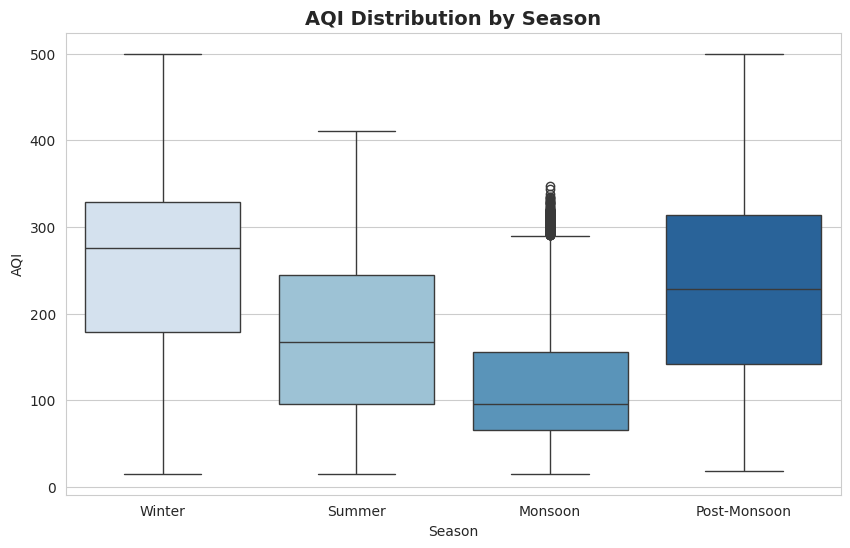

In [16]:
aqi_colors = {
    "Good": "#4CAF50", "Satisfactory": "#9ACD32", "Moderate": "#FFC107",
    "Poor": "#FF7043", "Very Poor": "#E53935", "Severe": "#7B1E3A"
}

plt.figure(figsize=(10, 6))
sns.boxplot(x="Season", y="AQI", data=df,
            order=["Winter", "Summer", "Monsoon", "Post-Monsoon"],
            palette="Blues")
plt.title("AQI Distribution by Season", fontsize=14, fontweight="bold")
plt.xlabel("Season")
plt.ylabel("AQI")
plt.show()

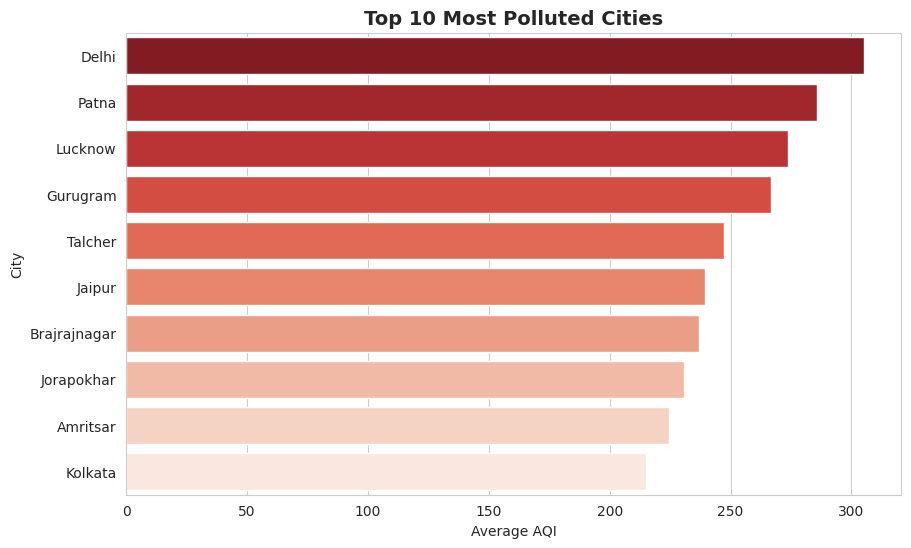

In [17]:
top_cities = df.groupby("City")["AQI"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_cities.values, y=top_cities.index, palette="Reds_r")
plt.title("Top 10 Most Polluted Cities", fontsize=14, fontweight="bold")
plt.xlabel("Average AQI")
plt.ylabel("City")
plt.show()

## Pollution Trend Over Time

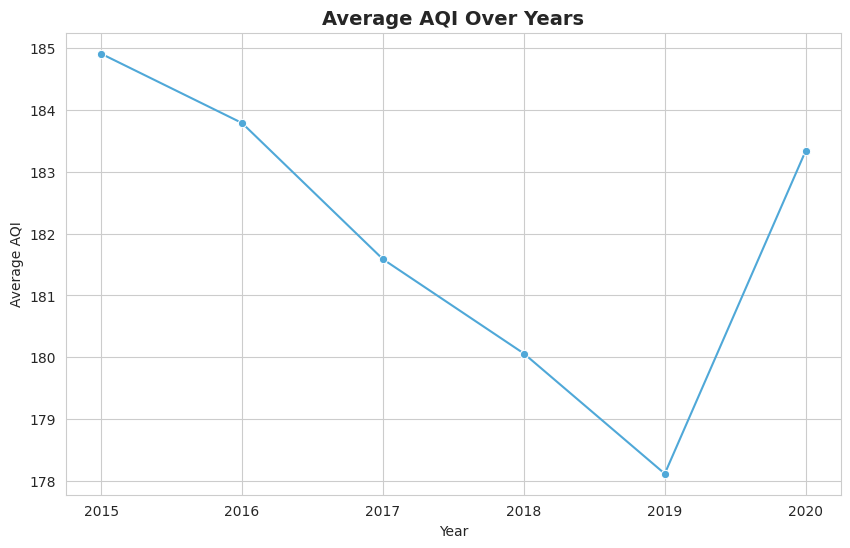

In [18]:
yearly_pollution = df.groupby("Year")["AQI"].mean()

plt.figure(figsize=(10, 6))
sns.lineplot(x=yearly_pollution.index, y=yearly_pollution.values, marker="o", color="#4FA8D8")
plt.title("Average AQI Over Years", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.show()

## Correlation Between Pollutants

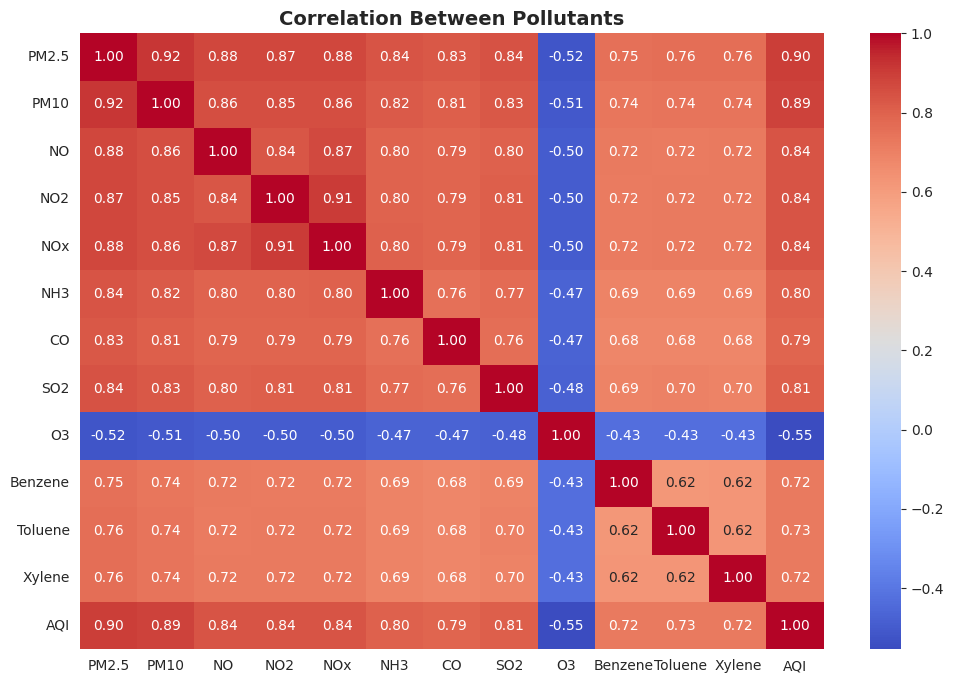

In [19]:
pollutants = ["PM2.5", "PM10", "NO", "NO2", "NOx", "NH3", "CO", "SO2", "O3", "Benzene", "Toluene", "Xylene", "AQI"]

plt.figure(figsize=(12, 8))
sns.heatmap(df[pollutants].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Pollutants", fontsize=14, fontweight="bold")
plt.show()

# Modeling: Predicting AQI

## Prepare Data for Modeling
One-hot encode categorical features (`City`, `Season`), define features (`X`) and target (`y`), then split
into train/test sets.

In [20]:
from sklearn.model_selection import train_test_split

numerical_features = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3',
                       'Benzene', 'Toluene', 'Xylene', 'Year', 'Month', 'Day']

y = df['AQI']

city_encoded = pd.get_dummies(df['City'], prefix='City')
season_encoded = pd.get_dummies(df['Season'], prefix='Season')

X = pd.concat([df[numerical_features], city_encoded, season_encoded], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (41766, 45)
X_test shape: (10442, 45)
y_train shape: (41766,)
y_test shape: (10442,)


## Train a Regression Model

In [21]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=120, max_depth=14, min_samples_leaf=3, n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)

print("RandomForestRegressor model trained successfully.")

RandomForestRegressor model trained successfully.


## Evaluate the Model

In [22]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2) Score: {r2:.3f}")

Mean Absolute Error (MAE): 13.38
R-squared (R2) Score: 0.928


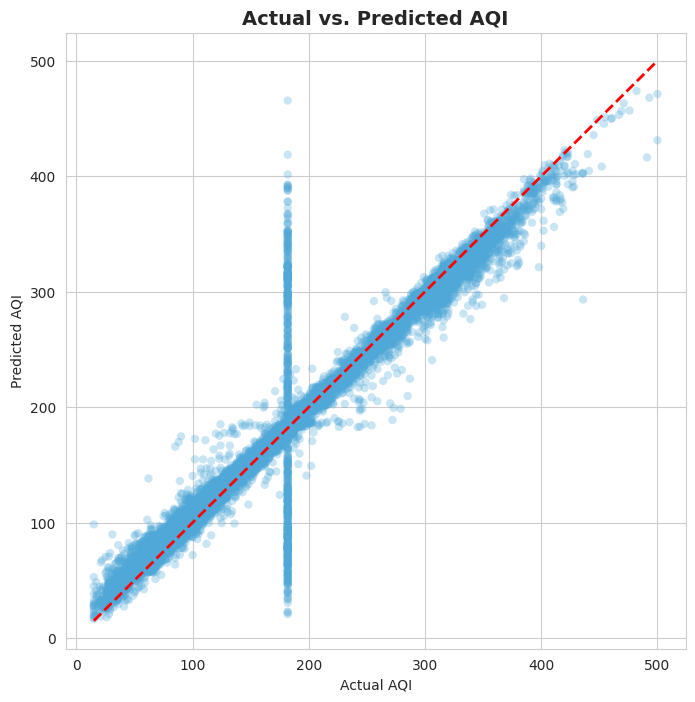

In [23]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.3, color="#4FA8D8", edgecolor="none")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs. Predicted AQI", fontsize=14, fontweight="bold")
plt.show()

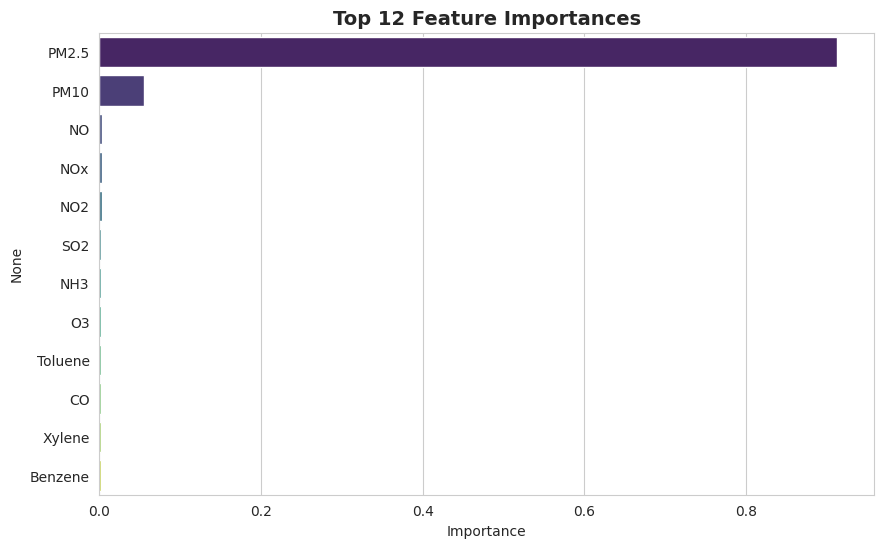

In [24]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Top 12 Feature Importances", fontsize=14, fontweight="bold")
plt.xlabel("Importance")
plt.show()

# Model Persistence

## Save the Trained Model
Save `rf_model` to disk with `pickle` so it can be reused without retraining (this is exactly what
`src/train_model.py` does for the dashboard).

In [25]:
import pickle

model_filename = os.path.join("..", "models", "random_forest_aqi_model.pkl")
os.makedirs(os.path.dirname(model_filename), exist_ok=True)

with open(model_filename, 'wb') as file:
    pickle.dump(rf_model, file)

print(f"RandomForestRegressor model saved successfully to {model_filename}")

RandomForestRegressor model saved successfully to ../models/random_forest_aqi_model.pkl


## Load the Saved Model

In [26]:
with open(model_filename, 'rb') as file:
    loaded_model = pickle.load(file)

print(f"RandomForestRegressor model loaded successfully from {model_filename}")

RandomForestRegressor model loaded successfully from ../models/random_forest_aqi_model.pkl


## Make a Prediction with the Loaded Model

In [27]:
all_features = X.columns.tolist()

sample_input = pd.DataFrame(0, index=[0], columns=all_features)

sample_input['PM2.5'] = 50.0
sample_input['PM10'] = 100.0
sample_input['NO'] = 10.0
sample_input['NO2'] = 20.0
sample_input['NOx'] = 30.0
sample_input['NH3'] = 15.0
sample_input['CO'] = 1.0
sample_input['SO2'] = 8.0
sample_input['O3'] = 40.0
sample_input['Benzene'] = 2.0
sample_input['Toluene'] = 5.0
sample_input['Xylene'] = 1.0
sample_input['Year'] = 2023
sample_input['Month'] = 1
sample_input['Day'] = 15

if 'City_Delhi' in all_features:
    sample_input['City_Delhi'] = 1
if 'Season_Winter' in all_features:
    sample_input['Season_Winter'] = 1

predicted_aqi = loaded_model.predict(sample_input)

print(f"Predicted AQI for the sample input: {predicted_aqi[0]:.2f}")

Predicted AQI for the sample input: 101.31


## Summary

### Key Findings
- Winter months show the sharpest AQI spikes across nearly every city, driven by temperature inversion and
  crop-residue burning; the monsoon season shows the strongest improvement due to rain washout.
- Delhi, Patna, Lucknow, and Gurugram consistently rank as the most polluted cities in the dataset.
- PM2.5 and PM10 are the dominant drivers of AQI, showing the strongest correlation with the target.
- A Random Forest Regressor trained on pollutant readings plus engineered Year/Month/Day/Season/City
  features predicts AQI with a strong R² score, confirming that pollutant concentrations plus seasonal and
  geographic context are highly informative for AQI estimation.
- The trained model was successfully saved, reloaded, and used for inference — a complete, reproducible
  model-persistence workflow.

### Next Steps
- Swap the synthetic `data/city_day.csv` for the real CPCB dataset (same column layout) to move from a
  demo to a production analysis.
- Explore the same predictions interactively in the **Streamlit dashboard** (`app.py`) included in this
  project — run `streamlit run app.py` from the project root.
